In [ ]:
from typing import Literal

from langgraph.graph import END, START, StateGraph
from functools import lru_cache
import os
from uuid import uuid4
from langchain_core.messages import AIMessage, HumanMessage, RemoveMessage
from langchain_core.runnables import RunnableConfig
from ai_companion.graph.utils.chains import get_router_chain
from ai_companion.settings import settings
from ai_companion.modules.memory.long_term.memory_manager import get_memory_manager

class AIComapanionState:
    summary: str
    workflow: str
    audio_buffer: bytes
    image_path: str 
    current_activity: str
    apply_activity: bool
    memory_context: str

async def router_node(state: AIComapanionState) -> AIComapanionState:
    """Based on the input this node will analyse and route to next node. it may be video, audio or text node
        Returns:
            anyone of the type: 'convesation', 'image', 'audio'
    """
    router_chain = get_router_chain()
    response = await router_chain.ainvoke({"messages": state["messages"][-settings.ROUTER_MESSAGES_TO_ANALYZE:]})
    print(response)
    return {"workflow": response.response_type}

async def memory_extraction_node(state: AIComapanionState):
    """Extract and store importatn information from the last messages"""
    if not state["messages"]:
        return {}
    
    memory_manager = get_memory_manager()
    memory_manager.extract_and_store_memories(state["messages"][-1])
    return {}



def context_injection_node(state: AIComapanionState) -> AIComapanionState:
    """This node will fetch the previous conversation memories and push it into current agent memory state"""
    return {"apply_activity": "apply_activity", "current_activity":"current_activity"}

def conversation_node(state: AIComapanionState) -> AIComapanionState: 
    """"""
    return {"messages": "AI Mesage"}

async def summarize_conversation_node(state:AIComapanionState):
    """Summarize the last n number of conversation and update the state accordingly"""
    return {"summary": "summary", "messages":"messages"}

def audio_node(state: AIComapanionState):
    """Handle all audio processing"""
    return{"messages":"response from ai", "audio_buffer":"output_audio" }

def image_node(state:AIComapanionState):
    """Handle all image processing """
    return{"messages":"response from ai","image_path":"output_path"}



async def memory_injection_node(state: AIComapanionState):
    """Retrive and inject relevant memories into the character card."""
    return {"memory_context" : "context"}



def should_summarize_conversation(
    state: AIComapanionState,
) -> Literal["summarize_conversation_node", "__end__"]:
    messages = state["messages"]

    if len(messages) > "settings.TOTAL_MESSAGES_SUMMARY_TRIGGER":
        return "summarize_conversation_node"

    return END


def select_workflow(
    state: AIComapanionState,
) -> Literal["conversation_node", "image_node", "audio_node"]:
    workflow = state["workflow"]

    if workflow == "image":
        return "image_node"

    elif workflow == "audio":
        return "audio_node"

    else:
        return "conversation_node"


SyntaxError: invalid syntax (1629090701.py, line 37)

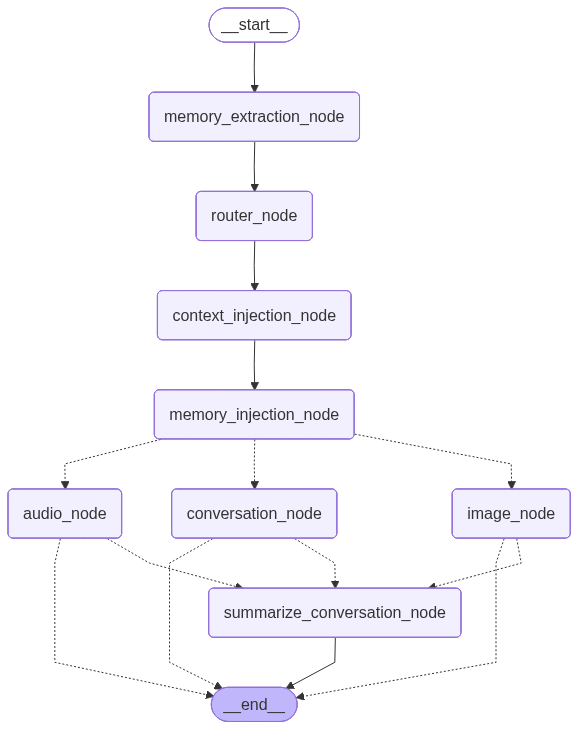

In [13]:
####Graph

from langgraph.graph import END, START, StateGraph
from IPython.display import Image,display
graph_builder= StateGraph(AIComapanionState)

graph_builder.add_node("memory_extraction_node", memory_extraction_node)
graph_builder.add_node("router_node", router_node)
graph_builder.add_node("context_injection_node", context_injection_node)
graph_builder.add_node("memory_injection_node", memory_injection_node)
graph_builder.add_node("conversation_node", conversation_node)
graph_builder.add_node("image_node", image_node)
graph_builder.add_node("audio_node", audio_node)
graph_builder.add_node("summarize_conversation_node", summarize_conversation_node)

# Define the flow
# First extract memories from user message
graph_builder.add_edge(START, "memory_extraction_node")

# Then determine response type
graph_builder.add_edge("memory_extraction_node", "router_node")

# Then inject both context and memories
graph_builder.add_edge("router_node", "context_injection_node")
graph_builder.add_edge("context_injection_node", "memory_injection_node")

# Then proceed to appropriate response node
graph_builder.add_conditional_edges("memory_injection_node", select_workflow)

# Check for summarization after any response
graph_builder.add_conditional_edges("conversation_node", should_summarize_conversation)
graph_builder.add_conditional_edges("image_node", should_summarize_conversation)
graph_builder.add_conditional_edges("audio_node", should_summarize_conversation)
graph_builder.add_edge("summarize_conversation_node", END)

graph_builder=graph_builder.compile()
png_graph = graph_builder.get_graph().draw_mermaid_png()
display(Image(png_graph))



In [14]:
###Debug router note in isolation
from langchain_core.messages import HumanMessage
import asyncio

test_state = {
    "messages": [
        HumanMessage(content="Can you send me image of a sunset")
    ],
    "wokrflow": "",
    "summary": "",
    "audio_buffer":b"",
    "image_path": "",
    "current_activity": "",
    "apply_activity": False,
    "memory_context": ""
}

results = await router_node(test_state)
print("Result",results)

response_type='image'
Result {'workflow': 'image'}


In [ ]:
test_state = {
    "messages": [
        HumanMessage(content="Who are you")
    ],
    "wokrflow": "image",
    "summary": "",
    "audio_buffer":b"",
    "image_path": "",
    "current_activity": "",
    "apply_activity": False,
    "memory_context": ""
}

